### Example 3 for the usage of Rela²x.
### See README.md for more information.

- ¹H and ¹⁴N nuclei.

- Dipole-dipole coupling between the spins, CSA and quadrupolar interactions on the ¹⁴N nucleus.

- Ranks $l = 2$ for each interaction.

Import Rela²x.

In [1]:
from rela2x import *

Define the spin system.

In [2]:
spin_system = ['1H', '14N']

Define the incoherent interactions.

In [3]:
dd_couplings = [[0, 1],
                [0, 0]]
sh_interactions = [0, 1]
q_interactions = [0, 1]

intrs = {'CSA': ('1L', sh_interactions, [2]),
         'Q':   ('1Q', q_interactions, [2]),
         'DD':  ('2', dd_couplings, [2])}

Compute the relaxation superoperator in the direct product basis of spherical tensor operators and create a RelaxationSuperoperator object.

Use the second version of basis sorting.

In [4]:
R = R_object_in_prodop_basis(spin_system, intrs, sorting='v2')


Computing R for interaction pairs...
CSA2 * CSA2
CSA2 * Q2
CSA2 * DD12
Q2 * CSA2
Q2 * Q2
Q2 * DD12
DD12 * CSA2
DD12 * Q2
DD12 * DD12
R computed.

Changing basis...
Basis changed.

Final clean-ups...
Done.


Visualize $R$ with a bit smaller fontsize. 

The block-diagonal structure is clearly visible.

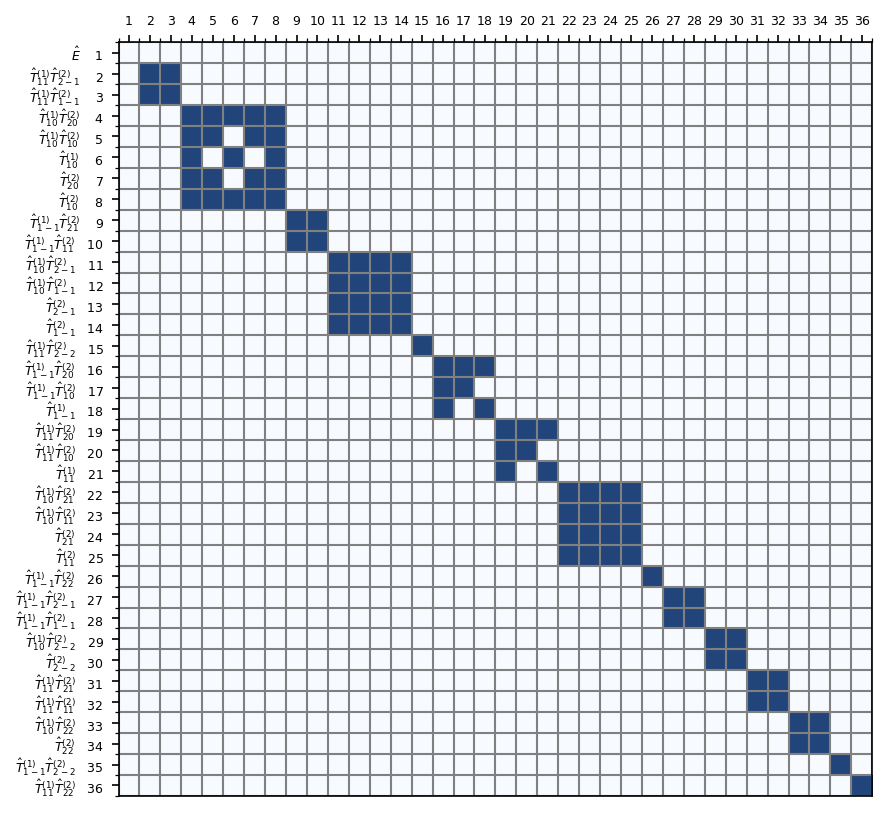

In [5]:
R.visualize(basis_symbols=R.basis_symbols, fontsize=7)

Check the auto-relaxation rate of $\hat T_{1-1}^{(2)}$, and the cross-relaxation rate between operators $\hat T_{1-1}^{(2)}$ and $\hat T_{10}^{(1)} \hat T_{1-1}^{(2)}$

In [6]:
rate1 = R.rate('21-1')
rate2 = R.rate('21-1', '110*21-1')

display(rate1)
display(rate2)

J^{CSA2}_{(2, 0)}(0)/3 + J^{CSA2}_{(2, 0)}(Abs(\omega_{14N}))/4 + J^{DD12}_{(2, 0)}(0)/12 + J^{DD12}_{(2, 0)}(Abs(\omega_{14N}))/16 + J^{DD12}_{(2, 0)}(Abs(\omega_{1H}))/8 + J^{DD12}_{(2, 0)}(Abs(\omega_{14N} - \omega_{1H}))/48 + J^{DD12}_{(2, 0)}(Abs(\omega_{14N} + \omega_{1H}))/8 + 3*J^{Q2}_{(2, 0)}(0)/4 + 5*J^{Q2}_{(2, 0)}(Abs(\omega_{14N}))/4 + J^{Q2}_{(2, 0)}(2*Abs(\omega_{14N}))/2

2*J^{DD12, CSA2}_{(2, 0)}(0)/3 + J^{DD12, CSA2}_{(2, 0)}(Abs(\omega_{14N}))/2

Check cross-relaxation rate between operators $\hat T_{1-1}^{(2)}$ and $\hat T_{10}^{(1)} \hat T_{2-1}^{(2)}$

In [7]:
rate = R.rate('21-1', '110*22-1')
display(rate)

sqrt(2)*J^{DD12, Q2}_{(2, 0)}(0) + sqrt(2)*J^{DD12, Q2}_{(2, 0)}(Abs(\omega_{14N}))/2 + sqrt(2)*J^{DD12}_{(2, 0)}(Abs(\omega_{14N} - \omega_{1H}))/24 - sqrt(2)*J^{DD12}_{(2, 0)}(Abs(\omega_{14N} + \omega_{1H}))/4

Use isotropic rotational diffusion model in the fast-motion limit and neglect all cross-correlated couplings.

In [8]:
R.to_isotropic_rotational_diffusion(fast_motion_limit=True)
R.neglect_cross_correlated_terms()

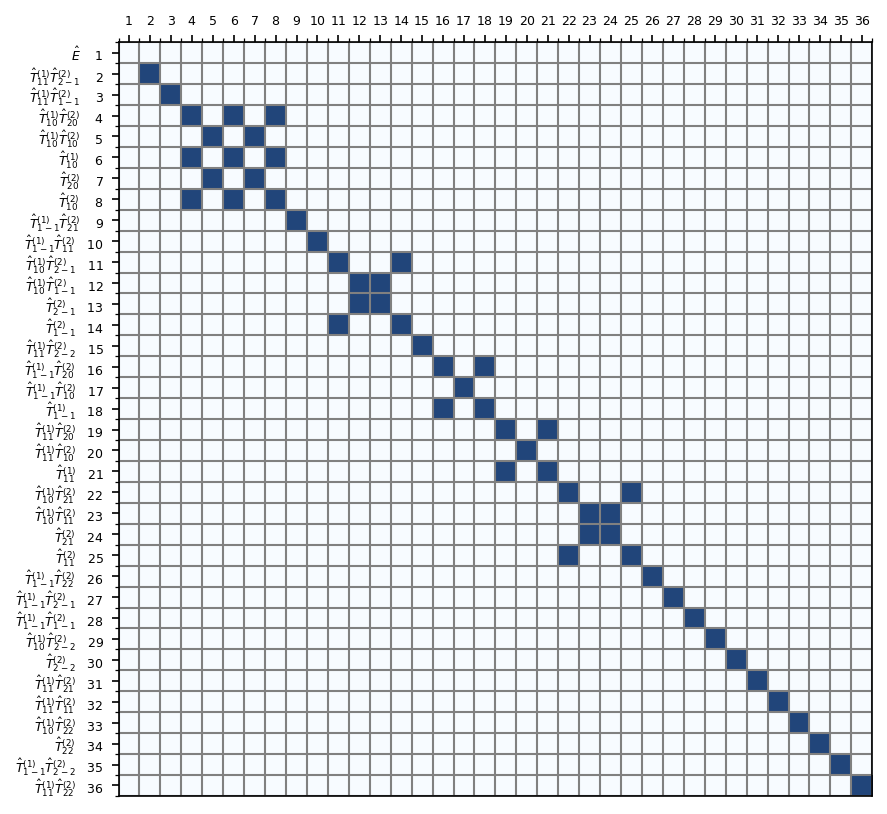

In [9]:
R.visualize(fontsize=7, basis_symbols=R.basis_symbols)

Check again the auto-relaxation rate of $\hat T_{1-1}^{(2)}$, and the cross-relaxation rate between operators $\hat T_{1-1}^{(2)}$ and $\hat T_{10}^{(1)} \hat T_{1-1}^{(2)}$

In [10]:
rate1 = R.rate('21-1')
rate2 = R.rate('21-1', '110*21-1')

display(rate1)
display(rate2)

7*\tau_c*G^{CSA2}_{(2, 0)}(0)/6 + 5*\tau_c*G^{DD12}_{(2, 0)}(0)/6 + 5*\tau_c*G^{Q2}_{(2, 0)}(0)

0

Filter out coherences other than 0

In [11]:
R.filter('c', [0])

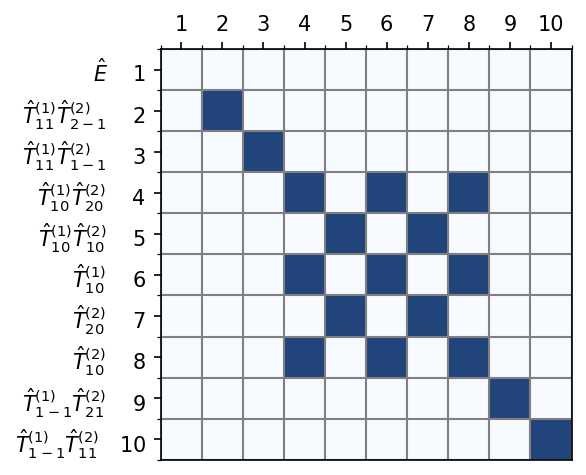

In [12]:
R.visualize(basis_symbols=R.basis_symbols)